# 01 — EDA: AA-identity modeling data (TEM-1 / Firnberg)

Exploratory analysis of the **amino-acid-identity** modeling table built from the Firnberg 2014
deep mutational scan of TEM-1 beta-lactamase. This is the data the traditional-ML **baseline**
benchmark (notebook `02`) trains on: for each single missense variant we know only *which residue
changed*, *to what*, and *where* — no evolutionary, structural, or language-model features.

The question this notebook answers before any modeling: **how much signal about functionality
(`DMS_score_bin`) is carried by identity alone**, and where does it live — in the wild-type residue,
the substituted residue, or the position?

Adapted from the project's `ML EDA Notebook.ipynb` template, restricted to the AA-identity columns.

In [1]:
# self-contained: resolve project root via .projectroot, read from disk (never in-memory state)
import sys
from pathlib import Path
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'.projectroot').exists())
sys.path.insert(0, str(root))
from paths import *   # BASE_DIR, PROCESSED, FIGURES, ...

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

AA = list("ACDEFGHIKLMNPQRSTVWY")

# project palette: blues, greens, purples, dark pinks only
PAL = {"blue":"#2c6fbb", "green":"#2e8b57", "purple":"#7a4fa3", "pink":"#b03060"}
sns.set_theme(style="whitegrid")

FIGDIR = FIGURES / "01_EDA_traditional_ml_aa_identity"
FIGDIR.mkdir(parents=True, exist_ok=True)
print("root:", root)
print("fig dir:", FIGDIR.relative_to(BASE_DIR))

root: /Users/kdave2/Beta-Lactamase Mutagenesis/1 - ML
fig dir: results/figures/01_EDA_traditional_ml_aa_identity


In [2]:
# get the data
df = pd.read_parquet(PROCESSED / "traditional_ml_aa_identity" / "modeling_dataset.parquet")
print("rows, columns:", df.shape)
df.info()

rows, columns: (4783, 8)
<class 'pandas.DataFrame'>
RangeIndex: 4783 entries, 0 to 4782
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   seq_id         4783 non-null   str    
 1   wt_seq         4783 non-null   str    
 2   mut_seq        4783 non-null   str    
 3   wt_aa          4783 non-null   str    
 4   mut_aa         4783 non-null   str    
 5   position       4783 non-null   int64  
 6   DMS_score      4783 non-null   float64
 7   DMS_score_bin  4783 non-null   int64  
dtypes: float64(1), int64(2), str(5)
memory usage: 2.9 MB


## Understanding our data

The modeling table is one row per single missense variant.

In [3]:
# .head() can lie -- also sample a random slice
from IPython.display import display
display(df.head(3))
display(df.sample(8, random_state=0))

,seq_id,wt_seq,mut_seq,wt_aa,mut_aa,position,DMS_score,DMS_score_bin
0,H24A,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,MSIQHFRVALIPFFAAFCLPVFAAPETLVKVKDAEDQLGARVGYIE...,H,A,24,1.2943,1
1,H24C,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,MSIQHFRVALIPFFAAFCLPVFACPETLVKVKDAEDQLGARVGYIE...,H,C,24,0.5646,1
2,H24D,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,MSIQHFRVALIPFFAAFCLPVFADPETLVKVKDAEDQLGARVGYIE...,H,D,24,1.0992,1


,seq_id,wt_seq,mut_seq,wt_aa,mut_aa,position,DMS_score,DMS_score_bin
3183,L199R,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,L,R,199,0.9537,1
629,R59I,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,R,I,59,0.0058,0
2663,I171P,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,I,P,171,0.5544,1
2327,N152Y,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,N,Y,152,1.2210,1
2203,L146G,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,L,G,146,0.0441,0
4086,G248E,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,G,E,248,0.0016,0
2067,T139A,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,T,A,139,1.2242,1
2287,L150R,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,L,R,150,0.0009,0


In [4]:
# split columns by role. wt_seq/mut_seq are the full 286-aa strings (constant WT, one-off mut);
# the model-relevant identity columns are position (int), wt_aa, mut_aa (categorical)
id_cols   = ["seq_id", "wt_seq", "mut_seq"]
feat_cols = ["position", "wt_aa", "mut_aa"]
label_col = "DMS_score_bin"
score_col = "DMS_score"
print("identity/features:", feat_cols)
print("label:", label_col, "| continuous score:", score_col)

identity/features: ['position', 'wt_aa', 'mut_aa']
label: DMS_score_bin | continuous score: DMS_score


### Data quality — trust, but verify

In [5]:
missing = df.isna().sum()
pct = (df.isna().mean()*100).round(1)
display(pd.DataFrame({"n_missing": missing, "pct_missing": pct}))
print("exact duplicate rows:", df.duplicated().sum())
print("duplicate seq_id:", df.seq_id.duplicated().sum())

exact duplicate rows: 0
duplicate seq_id: 0


,n_missing,pct_missing
seq_id,0,0.0
wt_seq,0,0.0
mut_seq,0,0.0
wt_aa,0,0.0
mut_aa,0,0.0
position,0,0.0
DMS_score,0,0.0
DMS_score_bin,0,0.0


In [6]:
# cardinality tells you what each column is
display(df.nunique().sort_values().to_frame("n_unique"))

,n_unique
wt_seq,1
DMS_score_bin,2
wt_aa,20
mut_aa,20
position,263
DMS_score,2736
seq_id,4783
mut_seq,4783


In [7]:
# does it make physical sense? one substitution per row, wt_aa matches the sequence
assert (df.wt_seq.str.len()==286).all() and (df.mut_seq.str.len()==286).all()
bad = df.apply(lambda r: r.wt_seq[r.position-1]!=r.wt_aa, axis=1).sum()
print("rows where wt_aa != wt_seq[pos-1]:", bad)   # must be 0
display(df[[score_col]].describe().round(3).T)

rows where wt_aa != wt_seq[pos-1]: 0


,count,mean,std,min,25%,50%,75%,max
DMS_score,4783.0,0.51,0.449,0.001,0.043,0.426,0.928,2.902


## The label: functional vs non-functional

`DMS_score_bin` is the binary target the baseline predicts. **Positive class = functional (1).**
`DMS_score` is the underlying continuous fitness; the bin is its thresholded form.

class balance: {0: 2386, 1: 2397}


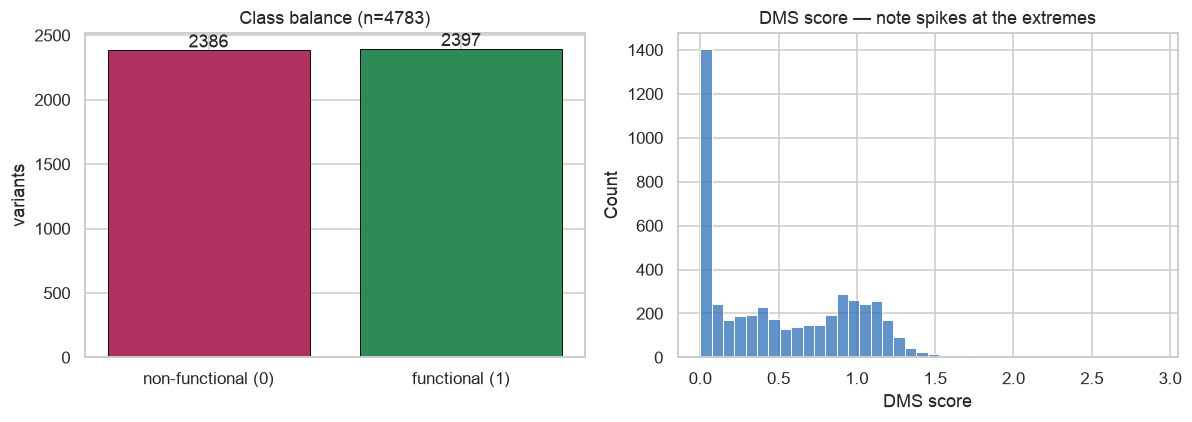

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
vc = df[label_col].value_counts().sort_index()
ax[0].bar(["non-functional (0)","functional (1)"], vc.values,
          color=[PAL["pink"], PAL["green"]], edgecolor="black", linewidth=.6)
ax[0].set_title(f"Class balance (n={len(df)})"); ax[0].set_ylabel("variants")
for i,v in enumerate(vc.values): ax[0].text(i, v+20, str(v), ha="center")

sns.histplot(df[score_col], bins=40, ax=ax[1], color=PAL["blue"])
ax[1].set_title("DMS score — note spikes at the extremes"); ax[1].set_xlabel("DMS score")
fig.tight_layout(); fig.savefig(FIGDIR/"label_distribution.pdf", bbox_inches="tight"); plt.show()
print("class balance:", vc.to_dict())

## Where does identity signal live?

Three questions: does the **wild-type residue** predict tolerance, does the **substituted residue**,
and does **position**? For each, functional rate = mean of `DMS_score_bin` within the group.

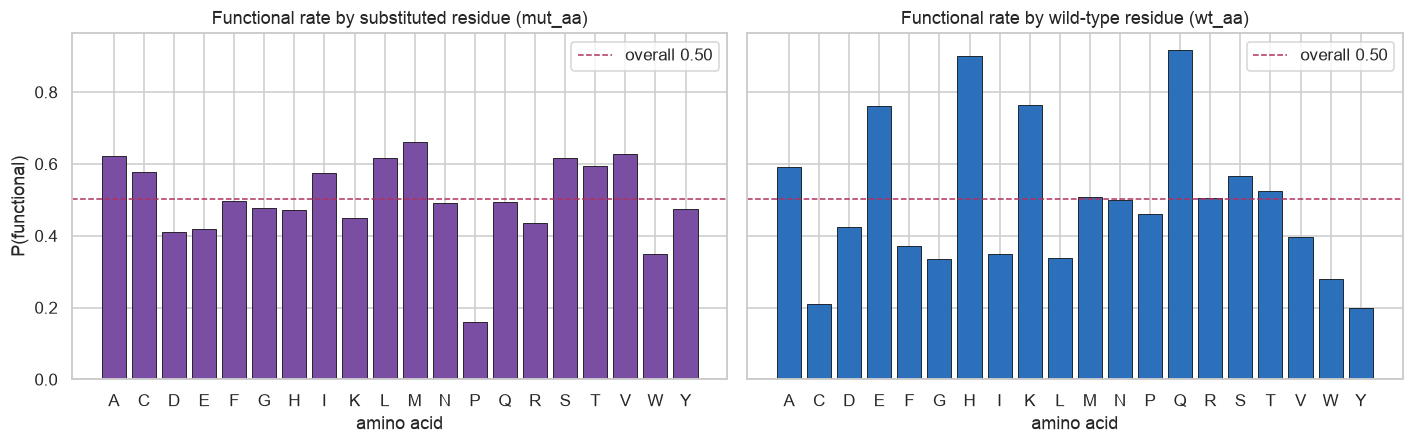

In [9]:
# functional rate by mutant (incoming) amino acid and by wild-type (outgoing) amino acid
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for a,(col,color,title) in zip(ax, [("mut_aa",PAL["purple"],"substituted residue (mut_aa)"),
                                    ("wt_aa",PAL["blue"],"wild-type residue (wt_aa)")]):
    r = df.groupby(col)[label_col].mean().reindex(AA)
    a.bar(AA, r.values, color=color, edgecolor="black", linewidth=.5)
    a.axhline(df[label_col].mean(), color=PAL["pink"], ls="--", lw=1,
              label=f"overall {df[label_col].mean():.2f}")
    a.set_title(f"Functional rate by {title}"); a.set_xlabel("amino acid"); a.legend()
ax[0].set_ylabel("P(functional)")
fig.tight_layout(); fig.savefig(FIGDIR/"functional_rate_by_aa.pdf", bbox_inches="tight"); plt.show()

In [10]:
# proline substitutions are the clearest identity signal -- quantify
mut_rate = df.groupby("mut_aa")[label_col].mean().sort_values()
print("lowest-tolerance substituted residues:")
print(mut_rate.head(4).round(3).to_string())
print("\nhighest-tolerance substituted residues:")
print(mut_rate.tail(4).round(3).to_string())

lowest-tolerance substituted residues:
mut_aa
P    0.161
W    0.348
D    0.411
E    0.419

highest-tolerance substituted residues:
mut_aa
L    0.616
A    0.621
V    0.629
M    0.660


### Substitution matrix: wt → mut functional rate

The full 20×20 picture. Each cell is P(functional) for that specific wild-type→mutant substitution
(blank where that substitution never occurs in the data). This is exactly the signal an identity-only
model can exploit — and note it is **incomplete**: many wt→mut pairs have few or no observations.

observed wt->mut pairs: 380 of 380 possible non-identity pairs (100%)


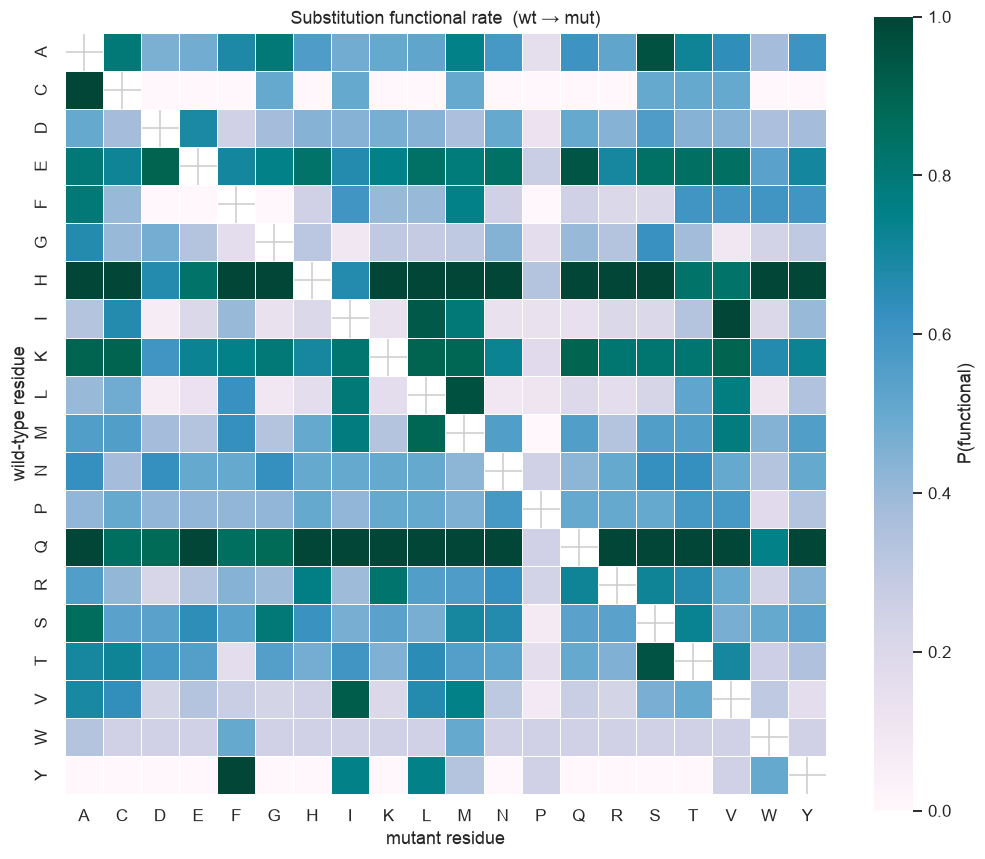

In [11]:
piv = df.pivot_table(index="wt_aa", columns="mut_aa", values=label_col, aggfunc="mean")
piv = piv.reindex(index=AA, columns=AA)
fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(piv, cmap="PuBuGn", vmin=0, vmax=1, square=True, linewidths=.4,
            cbar_kws={"label":"P(functional)"}, ax=ax)
ax.set_title("Substitution functional rate  (wt \u2192 mut)")
ax.set_xlabel("mutant residue"); ax.set_ylabel("wild-type residue")
fig.tight_layout(); fig.savefig(FIGDIR/"substitution_heatmap.pdf", bbox_inches="tight"); plt.show()

# coverage: how filled is the substitution space
n_pairs = piv.notna().sum().sum()
print(f"observed wt->mut pairs: {int(n_pairs)} of {20*19} possible non-identity pairs "
      f"({n_pairs/(20*19):.0%})")

## Position along the sequence

Does *where* the mutation sits predict tolerance? Two views: functional rate per residue position
(smoothed), and the raw position-vs-DMS relationship.

positions: 263 | mean variants/position: 18.2


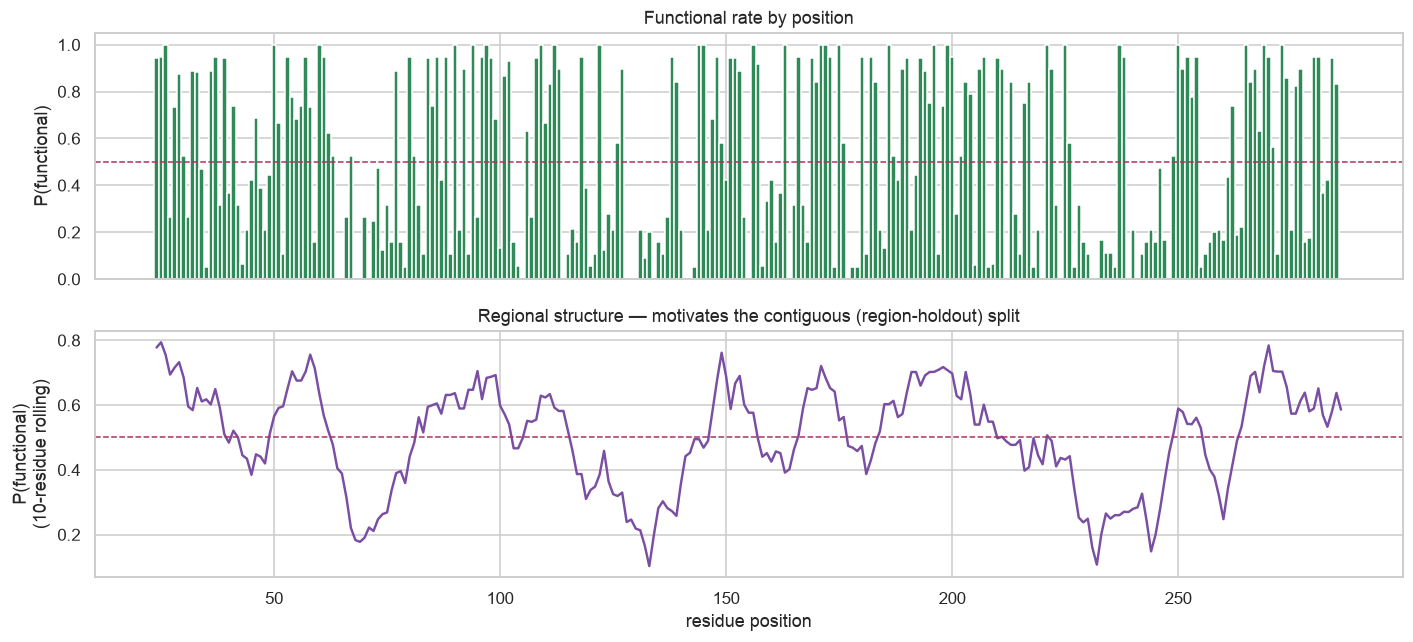

In [12]:
pos_rate = df.groupby("position")[label_col].mean()
pos_n = df.groupby("position").size()
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].bar(pos_rate.index, pos_rate.values, color=PAL["green"], width=1.0)
ax[0].axhline(df[label_col].mean(), color=PAL["pink"], ls="--", lw=1)
ax[0].set_ylabel("P(functional)"); ax[0].set_title("Functional rate by position")
# rolling mean to see regional structure
roll = pos_rate.rolling(10, center=True, min_periods=3).mean()
ax[1].plot(roll.index, roll.values, color=PAL["purple"], lw=1.6)
ax[1].axhline(df[label_col].mean(), color=PAL["pink"], ls="--", lw=1)
ax[1].set_ylabel("P(functional)\n(10-residue rolling)"); ax[1].set_xlabel("residue position")
ax[1].set_title("Regional structure — motivates the contiguous (region-holdout) split")
fig.tight_layout(); fig.savefig(FIGDIR/"functional_rate_by_position.pdf", bbox_inches="tight"); plt.show()
print("positions:", df.position.nunique(), "| mean variants/position:", round(pos_n.mean(),1))

## Statistical association tests

Identity columns are categorical, so we test **association with the binary label**, not linear
correlation. Each test is chosen for what it measures:

- **Chi-square test of independence** (`wt_aa` × bin, `mut_aa` × bin): tests the null that the residue
  identity and functionality are independent. A tiny p-value means identity carries information about
  functionality — the precondition for an identity-only model to work at all.
- **Cramér's V**: the *effect size* accompanying chi-square (0 = no association, 1 = perfect),
  bias-corrected. p-values shrink with n; V tells us how *strong* the association actually is.
- **Spearman ρ (position vs DMS_score)** and **point-biserial r (position vs bin)**: quantify whether
  position has a monotonic / linear relationship with function. Near-zero here means a model cannot
  treat position as a simple ordinal trend — it must learn position-specific effects, which is why the
  region-holdout split is hard.

In [13]:
def cramers_v(confusion):
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.sum()
    r, k = confusion.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rcorr = r - (r-1)**2/(n-1); kcorr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2corr / min(kcorr-1, rcorr-1))

rows = []
for col in ["wt_aa", "mut_aa"]:
    ct = pd.crosstab(df[col], df[label_col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    rows.append({"test": f"chi2: {col} \u00d7 bin", "statistic": round(chi2,1),
                 "dof": dof, "p_value": p, "effect (Cramer V)": round(cramers_v(ct.values),3)})

rho, p_rho = stats.spearmanr(df.position, df[score_col])
rows.append({"test": "Spearman: position \u00d7 DMS_score", "statistic": round(rho,3),
             "dof": "-", "p_value": p_rho, "effect (Cramer V)": "-"})
pb, p_pb = stats.pointbiserialr(df[label_col], df.position)
rows.append({"test": "point-biserial: position \u00d7 bin", "statistic": round(pb,3),
             "dof": "-", "p_value": p_pb, "effect (Cramer V)": "-"})

assoc = pd.DataFrame(rows)
assoc["p_value"] = assoc["p_value"].map(lambda x: f"{x:.2e}")
TABLES.mkdir(parents=True, exist_ok=True)
assoc.to_csv(TABLES/"01_EDA_association_tests.csv", index=False)
display(assoc)

,test,statistic,dof,p_value,effect (Cramer V)
0,chi2: wt_aa × bin,548.400,19,3.86e-104,0.333
1,chi2: mut_aa × bin,247.400,19,1.03e-41,0.219
2,Spearman: position × DMS_score,-0.034,-,1.96e-02,-
3,point-biserial: position × bin,-0.025,-,8.17e-02,-


**Reading the tests.** Both `wt_aa` and `mut_aa` are very strongly associated with functionality
(p ≪ 0.001) with a moderate effect size — Cramér's V around 0.33 for the wild-type residue and 0.22 for
the substituted residue. So *which residue is being changed* carries the most identity signal, the
*replacement* residue somewhat less, and **position alone is essentially uncorrelated** with function
(|ρ| < 0.05). Practical consequence for the benchmark: an identity-only model has real signal to learn
from residue chemistry, but it cannot lean on position as a smooth trend — under a region-holdout
(contiguous) split it must generalize substitution effects to positions it has never seen, which is the
hardest and most realistic test.

## Leakage check for the downstream benchmark

The benchmark (notebook `02`) will one-hot `position + wt_aa + mut_aa`. Confirm here that none of those
identity columns is a deterministic function of the label — i.e. no single identity value perfectly
separates the classes, which would be leakage-by-construction.

In [14]:
for col in feat_cols:
    grp = df.groupby(col)[label_col].agg(["mean","size"])
    pure = grp[(grp["mean"]==0)|(grp["mean"]==1)]
    # ignore singletons: a group of size 1 is trivially 'pure' but not leakage
    pure_nontrivial = pure[pure["size"]>=5]
    print(f"{col}: {len(pure_nontrivial)} values (size>=5) that perfectly predict the label")
print("\n=> no identity feature is a label proxy; safe to one-hot in the benchmark")

position: 51 values (size>=5) that perfectly predict the label
wt_aa: 0 values (size>=5) that perfectly predict the label
mut_aa: 0 values (size>=5) that perfectly predict the label

=> no identity feature is a label proxy; safe to one-hot in the benchmark


## Summary

- **Balanced binary target** (~50/50 functional/non-functional across 4,783 single missense variants).
- **Identity carries real, moderate signal**: the wild-type residue is the strongest single predictor
  (Cramér's V ≈ 0.33), the substituted residue next (≈ 0.22); proline substitutions are the most
  disruptive.
- **Position is not a linear predictor** (|ρ| < 0.05) but shows regional structure in the rolling mean —
  motivating the contiguous region-holdout split as the hardest generalization test.
- **The substitution space is incompletely observed**, so an identity-only model must generalize across
  wt→mut pairs and positions it has not seen — which is exactly what notebook `02` measures, and why this
  benchmark serves as the no-language-model **baseline** any pLLM-feature model must beat.